In [25]:
# analysis
import numpy as np
import pandas as pd 

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# single-cell
import scanpy as sc
import liana as li
import maboss

from pathlib import Path
import os 

# seting global dir
cwd=Path.cwd()
if cwd.name == "tutorials-basics":
    os.chdir(cwd.parent.parent) 
os.getcwd()

'/Users/max/Documents/repositories/MSB_project/notebooks'

### Bazy danych i referncje

In [3]:
adata = sc.datasets.pbmc68k_reduced()
adata

AnnData object with n_obs × n_vars = 700 × 765
    obs: 'bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain'
    var: 'n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

wizualizacja UMAP, pytania:
- w jaki sposób je rozdziela
- na czym tutaj polegają trajektorie
- względem czego to determinuje

no bo rozumiem, że celem jest rozróżnienie grup komórek, ale zastanawiam się czym się różnią poszczególne metody i w jaki sposób można je wykorzystać. 

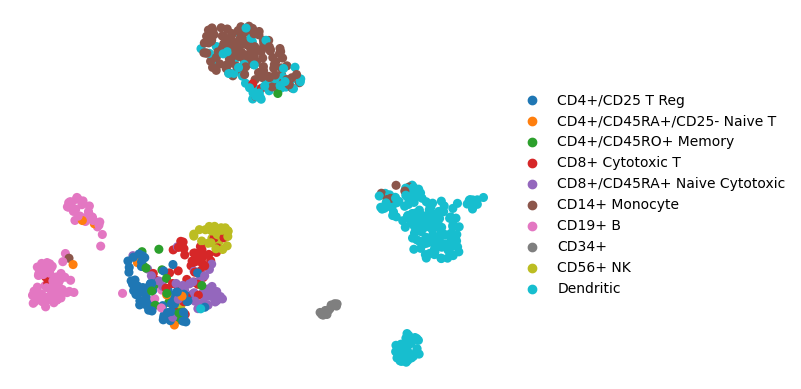

In [ ]:
sc.pl.umap(adata, color='bulk_labels', title='', frameon=False)

In [9]:
# tutaj możemy otrzymać informacje o danych
adata.raw.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 174400 stored elements and shape (700, 765)>

In [11]:
# dostępne methody z referencjami 
li.mt.show_methods()

,Method Name,Magnitude Score,Specificity Score,Reference
0,CellPhoneDB,lr_means,cellphone_pvals,"Efremova, M., Vento-Tormo, M., Teichmann, S.A...."
0,Connectome,expr_prod,scaled_weight,"Raredon, M.S.B., Yang, J., Garritano, J., Wang..."
0,log2FC,None,lr_logfc,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,NATMI,expr_prod,spec_weight,"Hou, R., Denisenko, E., Ong, H.T., Ramilowski,..."
0,SingleCellSignalR,lrscore,None,"Cabello-Aguilar, S., Alame, M., Kon-Sun-Tack, ..."
0,Rank_Aggregate,magnitude_rank,specificity_rank,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,Geometric Mean,lr_gmeans,gmean_pvals,CellPhoneDBv2's permutation approach applied t...
0,scSeqComm,inter_score,None,"Baruzzo, G., Cesaro, G., Di Camillo, B. 2022. ..."
0,CellChat,lr_probs,cellchat_pvals,"Jin, S., Guerrero-Juarez, C.F., Zhang, L., Cha..."


In [ ]:
# dostępne bazy danych z informacjami o ligand receptorach 
li.resource.show_resources()


['baccin2019',
 'cellcall',
 'cellchatdb',
 'cellinker',
 'cellphonedb',
 'celltalkdb',
 'connectomedb2020',
 'consensus',
 'embrace',
 'guide2pharma',
 'hpmr',
 'icellnet',
 'italk',
 'kirouac2010',
 'lrdb',
 'mouseconsensus',
 'ramilowski2015']

### Informacje z biblioteki

#### Notatki

Fragment o tym w jaki sposób dostajemy informacje z danej biblioteki



**Wyniki z komendy**

Rank_Aggregate returns `magnitude_rank`, `specificity_rank`. magnitude_rank and specificity_rank respectively represent an aggregate of the `magnitude`- and `specificity`-related scoring functions from the different methods.


#### Pytania

Przy ustawianiu [Prior knowledge](https://liana-py.readthedocs.io/en/latest/notebooks/prior_knowledge.html) jak i czy trzeba (bo rozumiem że w zależności od gatunku dostaniemy inne receptory i ligandy dla danych genów, bo to raczej powinno być bardziej uniwersalne) 

In [ ]:
from liana.mt import rank_aggregate
# informacja o metodzie agregacji 
# rank_aggregate.describe()
?rank_aggregate.__call__


Signature:
rank_aggregate.__call__(
    adata: 'an.AnnData | MuData',
    groupby: 'str',
    resource_name: 'str' = 'consensus',
    expr_prop: 'float' = 0.1,
    min_cells: 'int' = 5,
    groupby_pairs: 'DataFrame | None' = None,
    base: 'float' = np.float64(2.718281828459045),
    aggregate_method: 'str' = 'rra',
    consensus_opts: 'list | None' = None,
    return_all_lrs: 'bool' = False,
    key_added: 'str' = 'liana_res',
    use_raw: 'bool | None' = True,
    layer: 'str | None' = None,
    de_method: 'str' = 't-test',
    n_perms: 'int' = 1000,
    seed: 'int' = 1337,
    n_jobs: 'int' = 1,
    resource: 'DataFrame | None' = None,
    interactions: 'list | None' = None,
    mdata_kwargs: 'dict | None' = None,
    spatial_key: 'str | None' = None,
    spatial_kwargs: 'dict | None' = None,
    inplace: 'bool' = True,
    verbose: 'bool | None' = False,
)
Docstring:
Get an aggregate of ligand-receptor scores from multiple methods.

Parameters
----------
adata
    Annotated data 

In [ ]:
rank_aggregate.describe()

Rank_Aggregate returns `magnitude_rank`, `specificity_rank`. magnitude_rank and specificity_rank respectively represent an aggregate of the `magnitude`- and `specificity`-related scoring functions from the different methods.


### Analiza stanu stacjonarnego (steady state)

#### Pojedyncze metody

##### jakich macierzy i wiedzy prior (resources) używają metody liany

##### Macierze
- UWAGA: domyślnie liana używa `raw` data, żeby wybrac inną transformacje trzeba zdeterminować odpowiednią warstwę

##### Prior

Wiedza prior z baz danych, polega na odpowiednim mapowaniu genów (*symobli genetycznych* - w jednym gatunku są unikalne, między gatunkami niekoniecznie - problem z homologią )  

- UWAGA: domyśnie liana używa `resource_name='consensus'` czyli zbiera wszystkie dane i używa symboli genetycznych człowieka

#### Użyte statystyki - co robią? - opis danych 

##### Źródło (source) i cele (target) 
Identyfikujemy poprzez te zmienne komórki które wysyłają / odbierają komunikacje

##### ligand receptor complex_* ligandy, receptory ich kompleksy  
W komunikacji nie używamy oczywiście ligandów i receptorów, ponieważ CCC (cell-cell communication) jest bardziej złożona. Dodatkowo my wyłapujemy **tylko komplesy białkowe**, zatem my sprawdzamy ekspresje tylko po pod jednostakch ligandów / receptorów i mamy osobno nazwane jakiego kompleksu to jest fragment (bierzemy po minimum tego kompleksu) 

Pytanie:
- czym jest ptor entities, more specifically: ligand and receptor are the two entities that potentially interact. As a reminder, CCC events are not limited to secreted signalling, but we refer to them as ligand and receptor for simplicity.

##### *_props (proporcja) 
Tutaj mówimy w jakiej proporcji komórek występuje dany ligand / receptor. W przypadku małych zliczeń interpretujemy je jako false positive (tutaj interpretujey to tak, że w sposób losowy się tam znalazły) 

##### *_mean
**_means**

ile średnio danej danej ekspresji przypada na komórkę (ale to jaka jest skala to jest per milion genes wtedy czy po prosu ile zliczeń średnio)

**lr_means**

ile średnio jest ekspresji **na pary** ligand receptor - miara interakcji 

Proporcja komórek które mają

##### cellphone_pvals
Wyniki $p$ value po tych permutacyjnych testach jako miara **specyficzności** (wiele metryk musi pokazać zgodny wynik) 

##### Inne 
Metryki z różnych metryk, rozdzielamy je względem **siły(magnitutde)** działania danej pary ligand-receptor, oraz **specyficzność (specifity)** które możemy otrzymać

##### Pytania
- jak mamy *_means to w jaki sposób mamy rozumieć otrzymaną wartość?? Czy to świadczy o 


In [22]:
# import wszystkich metod
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

In [ ]:
# run cellphonedb
# UWAGA: domyślnie te metody są zapisywane w 'liana_res'
cellphonedb(adata,
            groupby='bulk_labels', 
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name='consensus',
            expr_prop=0.1 # co robi to ?? 
            verbose=True, 
            key_added='cpdb_res' # w jaki sposób zapisujemy nasze wyniki / domyślnie liana_res
            )

Using resource `consensus`.
Using `.raw`!
/Users/max/.micromamba/envs/sc_env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/Users/max/.micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.94 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 700 samples and 43 features


100%|██████████| 1000/1000 [00:01<00:00, 724.30it/s]


In [ ]:
adata.uns # to jest ogólnie słownik z unstructured annotation

{'variance': array([30.928047 , 21.182432 , 14.686322 , 11.570731 ,  9.232856 ,
         7.3497834,  4.338316 ,  3.197439 ,  3.1584399,  2.910167 ,
         2.649945 ,  2.540031 ,  2.4057367,  2.3872852,  2.2644212,
         2.2250588,  2.189688 ,  2.134691 ,  2.0775423,  2.0560663,
         2.007874 ,  1.9969993,  1.9606696,  1.9441428,  1.9129871,
         1.9063067,  1.8529838,  1.8260264,  1.7946786,  1.7489465,
         1.7449841,  1.7298484,  1.70099  ,  1.6571085,  1.6406441,
         1.6235017,  1.6012688,  1.5806534,  1.5531204,  1.5331998,
         1.5166894,  1.4852371,  1.4748584,  1.4530103,  1.4340347,
         1.4083625,  1.375356 ,  1.3701098,  1.356156 ,  1.3449155],
       dtype=float32),
 'variance_ratio': array([0.09770954, 0.06692067, 0.04639781, 0.03655487, 0.02916893,
        0.02321983, 0.01370584, 0.01010152, 0.00997831, 0.00919395,
        0.00837185, 0.0080246 , 0.00760033, 0.00754204, 0.00715388,
        0.00702952, 0.00691778, 0.00674403, 0.00656348, 0.0064

In [37]:
adata.uns['cpdb_res'].head()


,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
482,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.612842,0.421053,Dendritic,CD4+/CD45RO+ Memory,2.575263,0.0
321,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.596125,0.500000,Dendritic,CD4+/CD45RA+/CD25- Naive T,2.566905,0.0
989,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.483977,0.302326,Dendritic,CD14+ Monocyte,2.510830,0.0
651,HLA-DRA,HLA-DRA,4.537684,0.995833,LAG3,LAG3,0.399500,0.240741,Dendritic,CD8+ Cytotoxic T,2.468592,0.0
1392,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.373671,0.270833,Dendritic,Dendritic,2.455678,0.0


#### Wykresy

##### dotplot
- mamy iformacje o o tym ile było istotnych odczytów
- jaka była średnia ekspresja liganda i receptora

- wybrakowane 
-  byłī to fasle positive'y zostały wybrakowane 
  
##### Tileplot




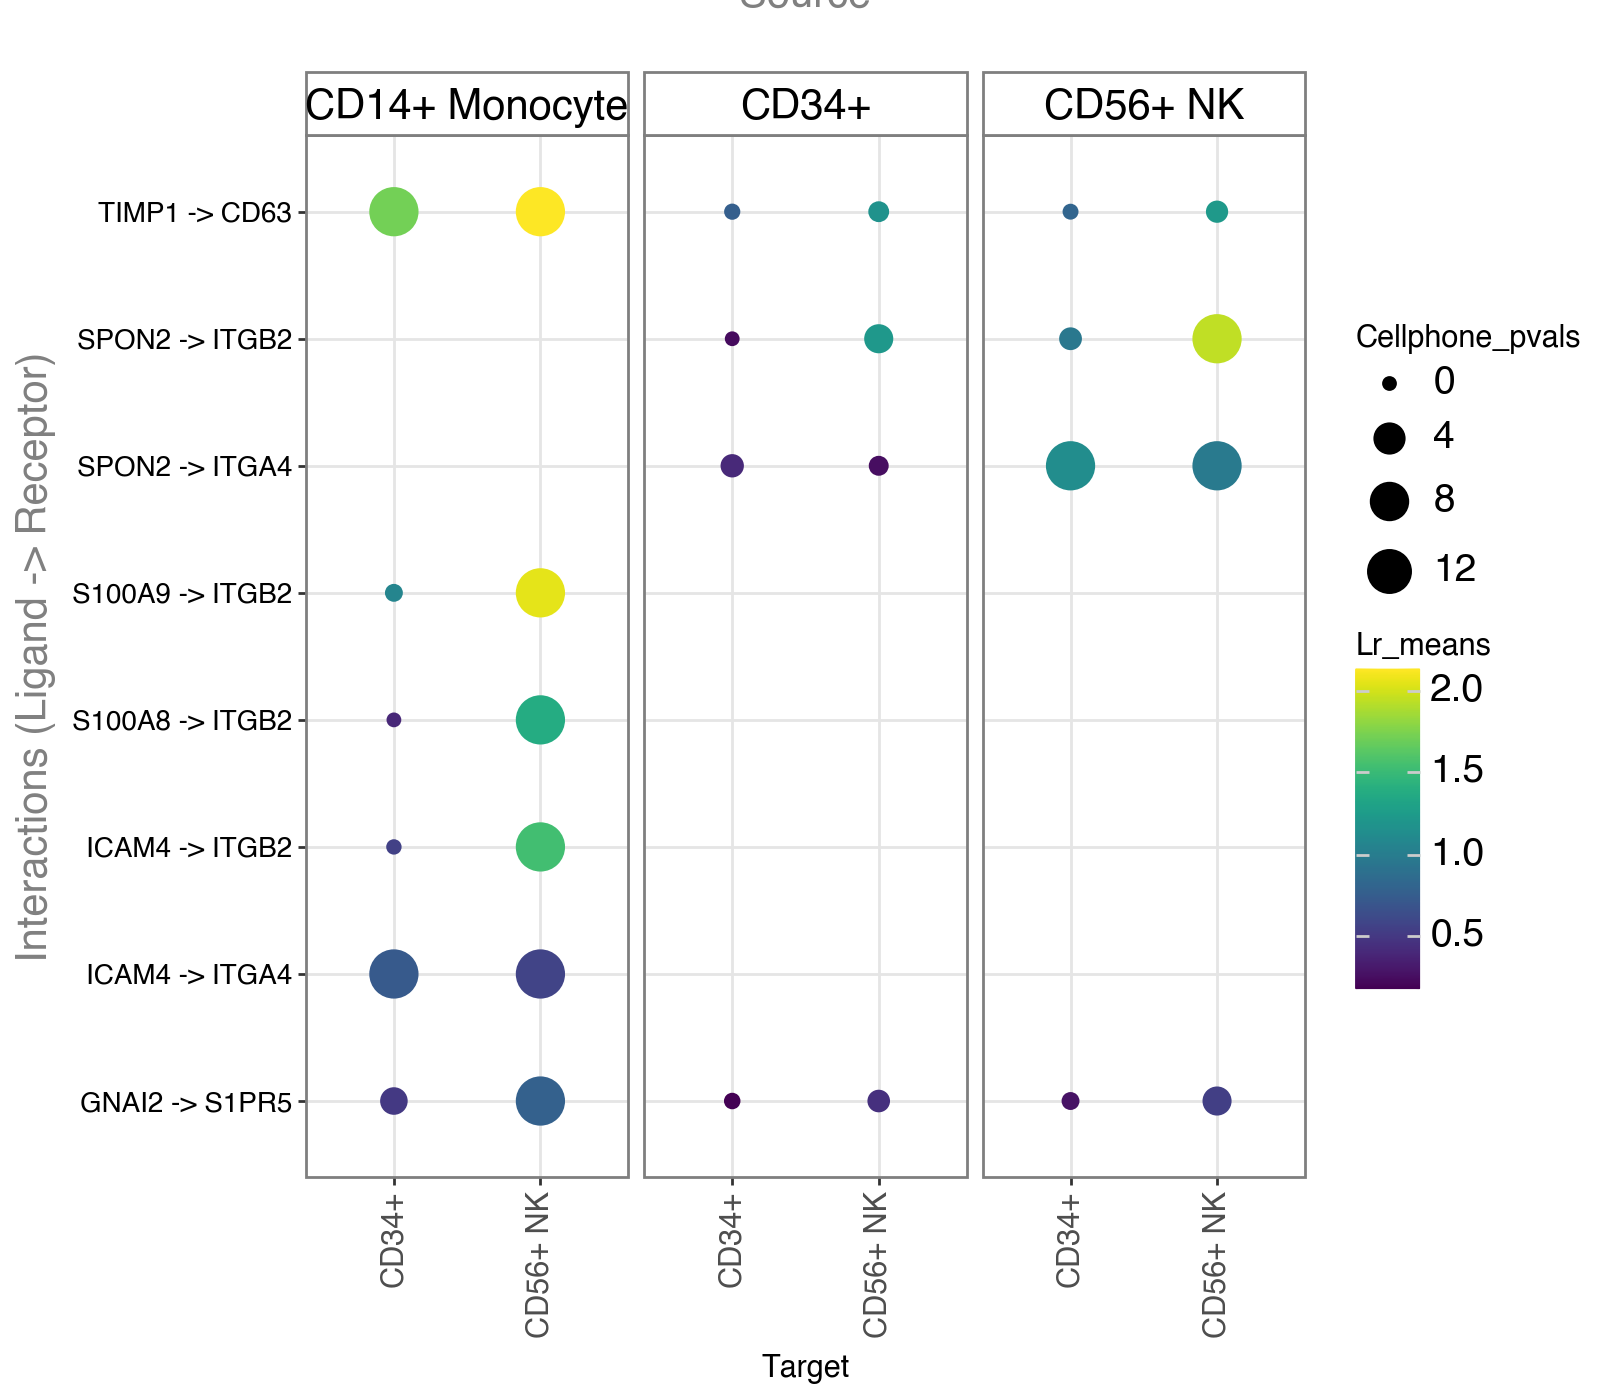

In [38]:
li.pl.dotplot(adata = adata, 
              colour='lr_means',
              size='cellphone_pvals',
              inverse_size=True, # we inverse sign since we want small p-values to have large sizes
              source_labels=['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
              target_labels=['CD34+', 'CD56+ NK'],
              figure_size=(8, 7),
              # finally, since cpdbv2 suggests using a filter to FPs
              # we filter the pvals column to <= 0.05
              filter_fun=lambda x: x['cellphone_pvals'] <= 0.05,
              uns_key='cpdb_res' # uns_key to use, default is 'liana_res' 
             )

/Users/max/.micromamba/envs/sc_env/lib/python3.12/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


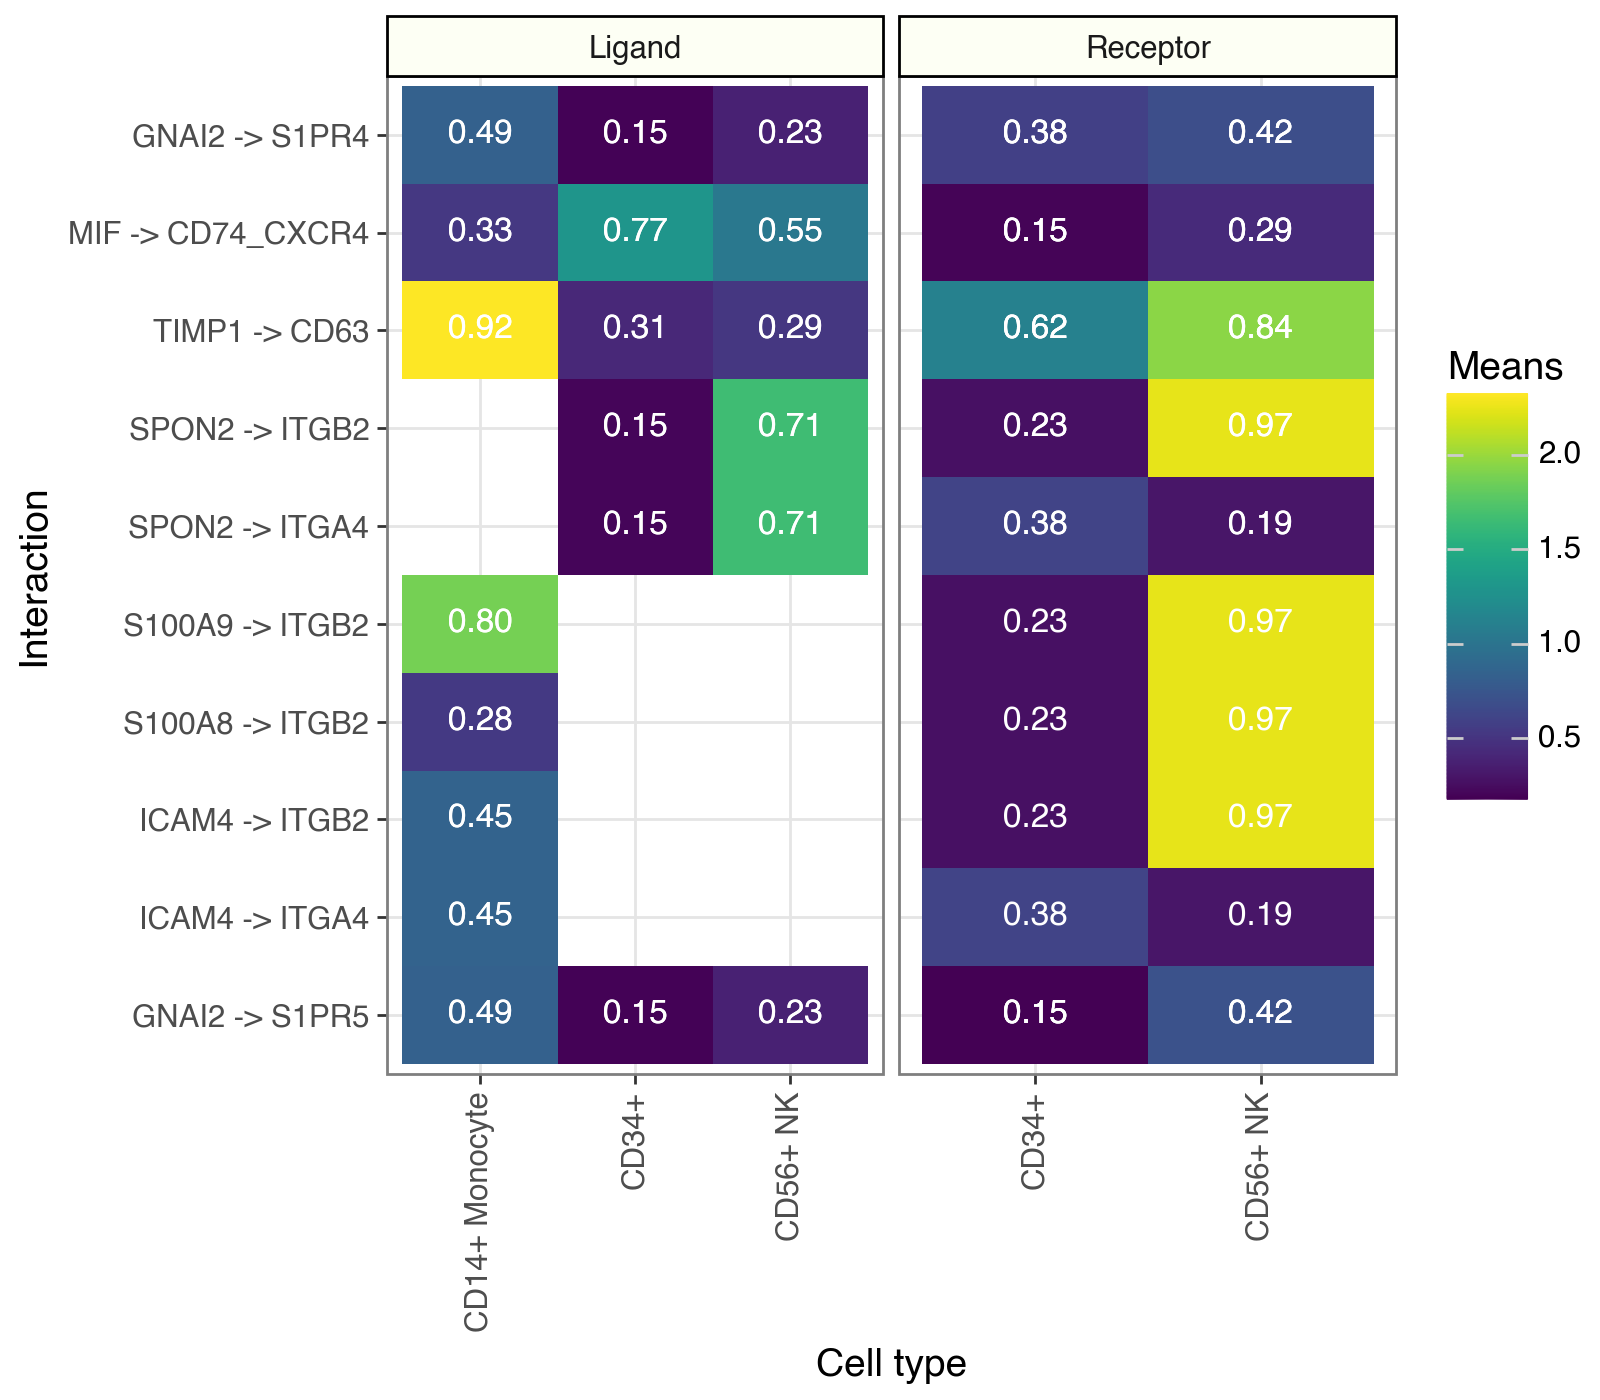

In [ ]:
my_plot = li.pl.tileplot(adata = adata, 
                         # NOTE: fill & label need to exist for both
                         # ligand_ and receptor_ columns
                         fill='means',
                         label='props',
                         label_fun=lambda x: f'{x:.2f}',
                         top_n=10, 
                         orderby='cellphone_pvals', #.TODO - tutaj jest ważne, ponieważ mo
                         orderby_ascending=True,
                         source_labels=['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
                         target_labels=['CD34+', 'CD56+ NK'],
                         uns_key='cpdb_res', # NOTE: default is 'liana_res'
                         source_title='Ligand',
                         target_title='Receptor',
                         figure_size=(8, 7)
                         )
my_plot

#### Grupowanie wielu metod

##### Rozpoznanie metod. 

przy methodzie rank_aggregate.describe() dostajemy opis jakie inne metody zostały użyte 

In [40]:
# Run rank_aggregate
li.mt.rank_aggregate(adata, 
                     groupby='bulk_labels',
                     resource_name='consensus',
                     expr_prop=0.1,
                     verbose=True)

Using resource `consensus`.
Using `.raw`!
/Users/max/.micromamba/envs/sc_env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/Users/max/.micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.94 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 700 samples and 43 features


/Users/max/.micromamba/envs/sc_env/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
/Users/max/.micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/Users/max/.micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
/Users/max/.micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:296: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.


Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [00:01<00:00, 756.32it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [42]:
adata.uns['liana_res']

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
1209,Dendritic,CD4+/CD45RO+ Memory,HLA-DRA,CD4,2.575263,0.000,2.780884,0.723815,1.431303,0.065077,0.736772,0.001137,0.000653
1188,Dendritic,CD4+/CD45RA+/CD25- Naive T,HLA-DRA,CD4,2.566905,0.000,2.705027,0.709428,1.332656,0.063302,0.734081,0.001137,0.000911
1210,Dendritic,CD4+/CD45RO+ Memory,HLA-DRB1,CD4,2.415010,0.000,2.584465,0.712731,1.331341,0.060203,0.729607,0.001137,0.001211
1205,Dendritic,CD4+/CD45RO+ Memory,HLA-DPB1,CD4,2.367473,0.000,2.526199,0.731297,1.447014,0.068953,0.727352,0.001137,0.001377
1189,Dendritic,CD4+/CD45RA+/CD25- Naive T,HLA-DRB1,CD4,2.406652,0.000,2.513965,0.698344,1.232695,0.058561,0.726870,0.001137,0.001741
...,...,...,...,...,...,...,...,...,...,...,...,...,...
780,CD56+ NK,CD14+ Monocyte,MIF,CD74_CXCR4,0.614663,0.780,0.202966,-0.094504,-0.178274,0.003595,0.430580,1.000000,1.000000
387,CD34+,CD8+ Cytotoxic T,LCK,CD8A_CD8B,0.431345,0.263,0.169229,0.285467,0.161054,0.009152,0.408449,0.791351,1.000000
734,CD4+/CD45RO+ Memory,CD8+ Cytotoxic T,HLA-DPA1,LAG3,0.447961,1.000,0.198320,-0.080977,-1.485975,0.015111,0.427743,1.000000,1.000000
774,CD56+ NK,CD14+ Monocyte,HLA-DPA1,CD4,0.469295,1.000,0.220022,-0.447806,-1.614551,0.005962,0.440498,1.000000,1.000000


In [ ]:

rank_aggregate.describe()


Rank_Aggregate returns `magnitude_rank`, `specificity_rank`. magnitude_rank and specificity_rank respectively represent an aggregate of the `magnitude`- and `specificity`-related scoring functions from the different methods.


/Users/max/.micromamba/envs/sc_env/lib/python3.12/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


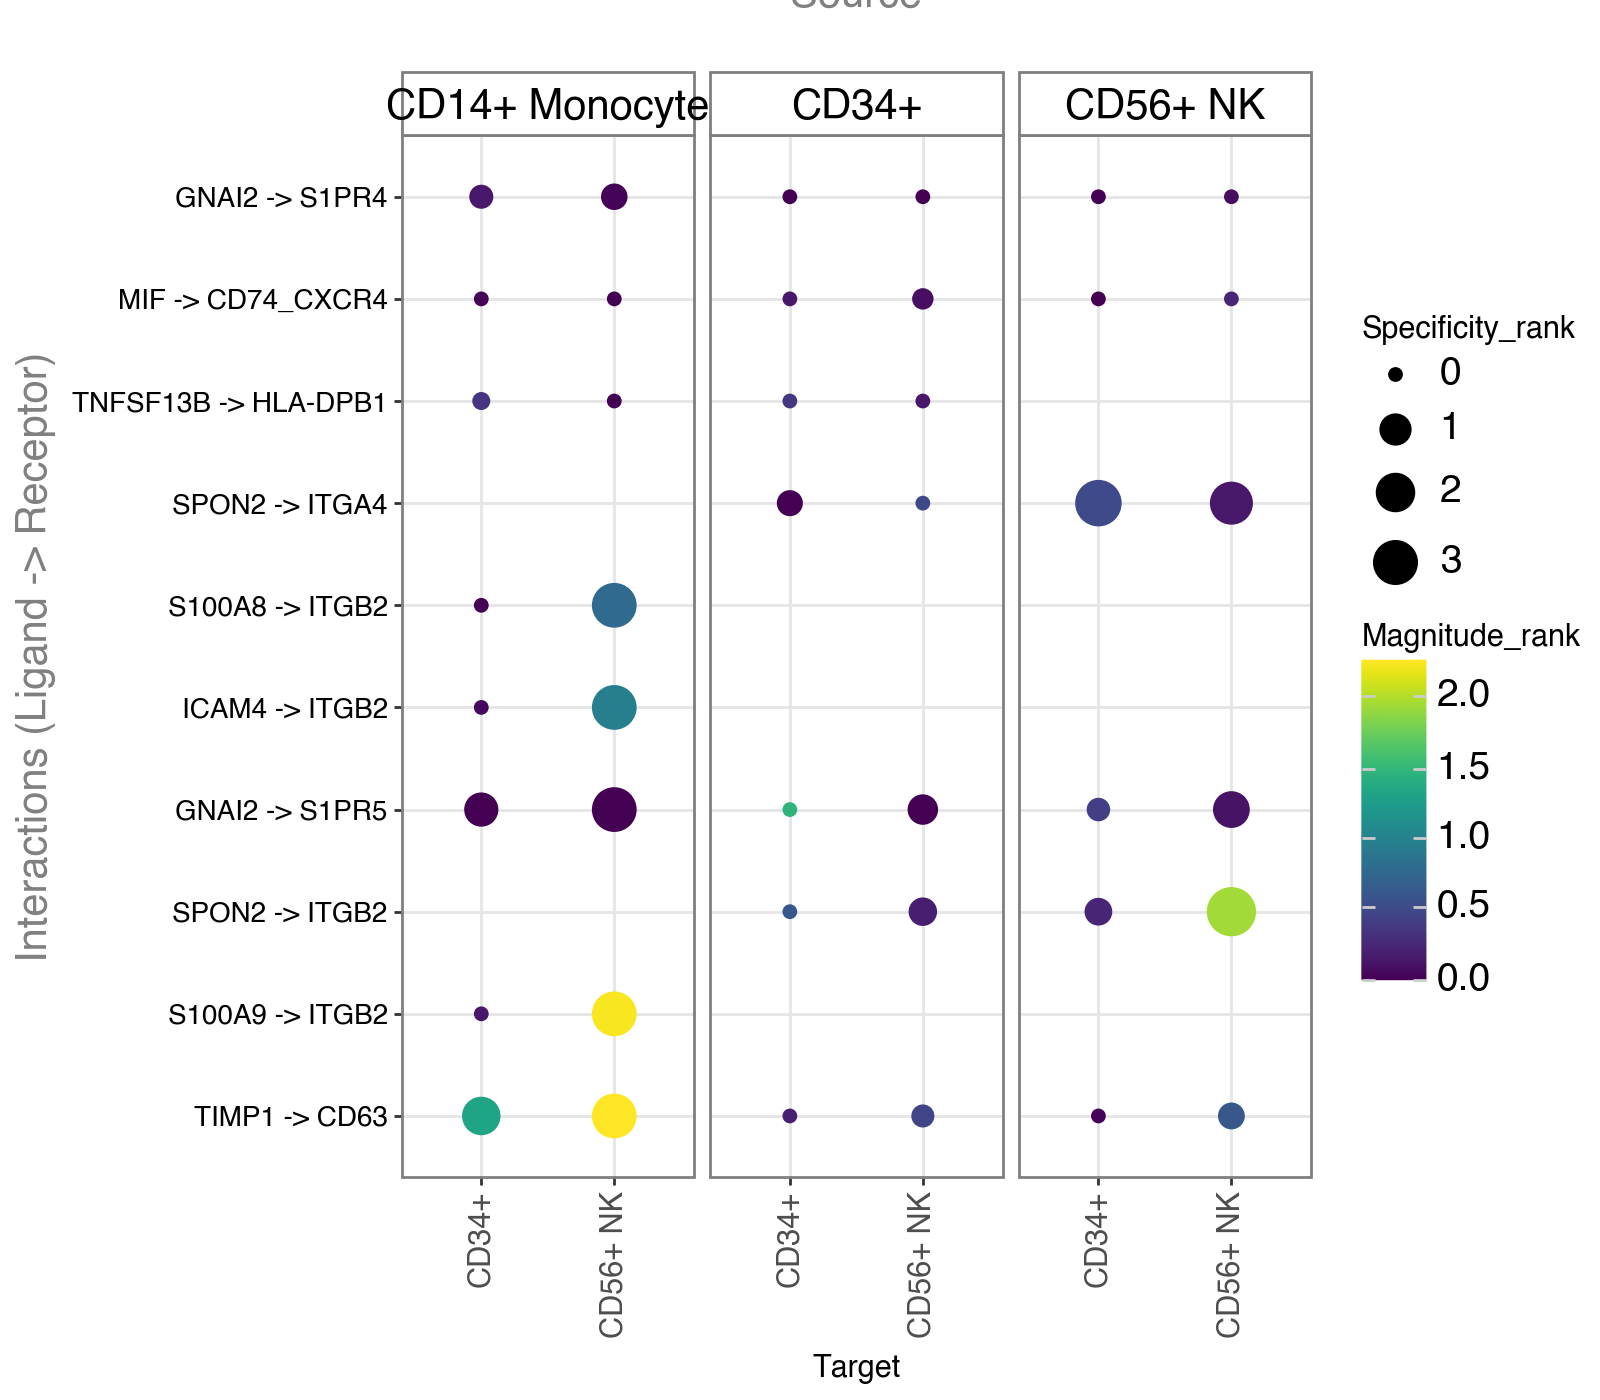

In [45]:
li.pl.dotplot(adata = adata, 
              colour='magnitude_rank',
              size='specificity_rank',
              inverse_size=True,
              inverse_colour=True,
              source_labels=['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
              target_labels=['CD34+', 'CD56+ NK'],
              top_n=10, 
              uns_key='liana_res',
              orderby='magnitude_rank',
              orderby_ascending=True,
              figure_size=(8, 7)
             )

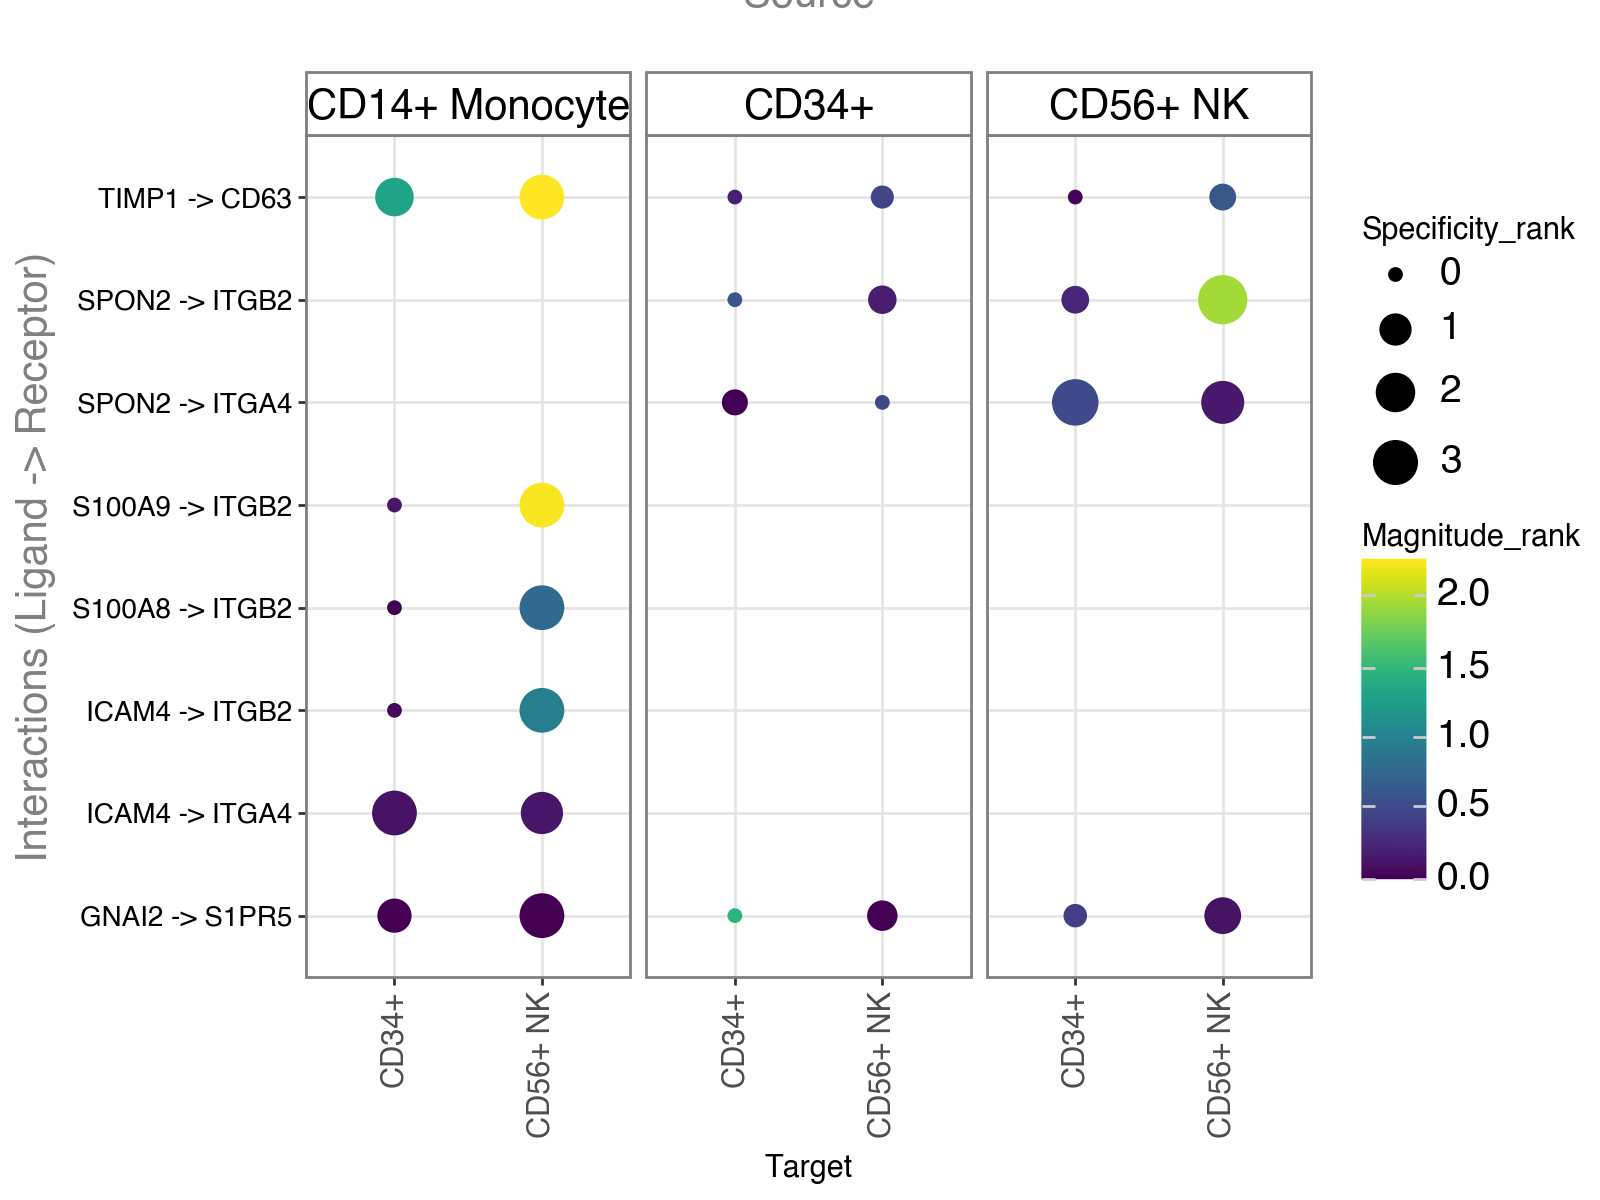

In [ ]:
li.pl.dotplot(adata = adata, 
                        colour='magnitude_rank',
                        inverse_colour=True,
                        size='specificity_rank',
                        inverse_size=True,
                        source_labels=['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
                        target_labels=['CD34+', 'CD56+ NK'],
                        # TODO - here we apply filter for obtaining only specify results 
                        filter_fun=lambda x: x['specificity_rank'] <= 0.01,
                       )

<Axes: >

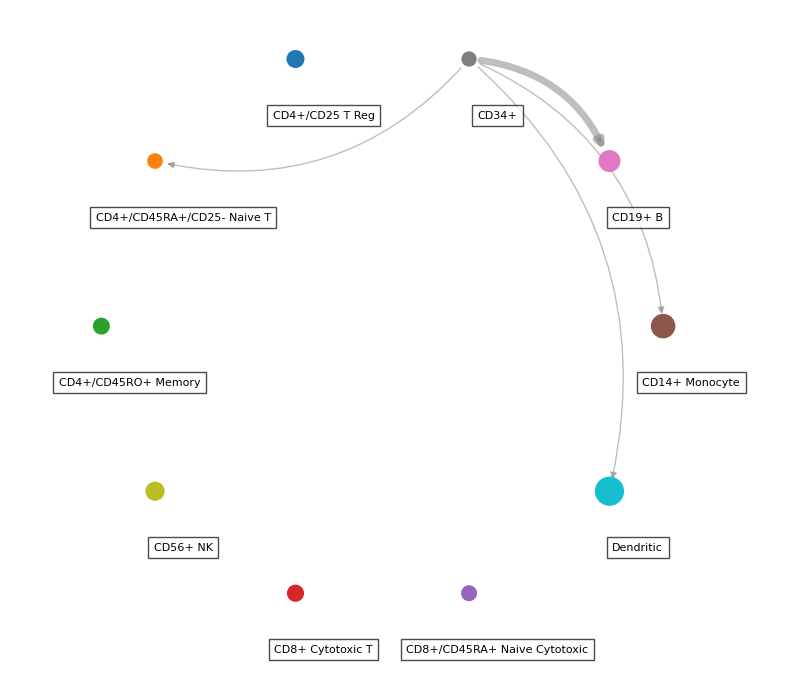

In [48]:
li.pl.circle_plot(adata,
                  groupby='bulk_labels',
                  score_key='magnitude_rank',
                  inverse_score=True,
                  source_labels='CD34+',
                  filter_fun=lambda x: x['specificity_rank'] <= 0.05,
                  pivot_mode='counts', # NOTE: this will simply count the interactions, 'mean' is also available
                  figure_size=(10, 10),
                  )

Using part of methods

In [50]:
methods = [logfc, geometric_mean]
new_rank_aggregate = li.mt.AggregateClass(li.mt.aggregate_meta, methods=methods)

In [51]:
new_rank_aggregate(adata,
                   groupby='bulk_labels',
                   expr_prop=0.1, 
                   verbose=True,
                   # Note that with this option, we don't perform permutations
                   # and hence we exclude the p-value for geometric_mean, as well as specificity_rank
                   n_perms=None,
                   use_raw=True,
                   )

Using resource `consensus`.
Using `.raw`!
/Users/max/.micromamba/envs/sc_env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/Users/max/.micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.94 of entities in the resource are missing from the data.
/Users/max/.micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
/Users/max/.micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:296: FutureWarning: Us

Generating ligand-receptor stats for 700 samples and 43 features
Assuming that counts were `natural` log-normalized!
Running log2FC
Running Geometric Mean


### mutlimodalna analiza

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import liana as li
import mudata as mu
from matplotlib import pyplot as plt

In [10]:
# set global figure parameters
kwargs = {'frameon':False, 'size':1.5, 'img_key':'lowres'}

In [ ]:
# let's download the data
rna = sc.read("sma_rna.h5ad", backup_url="https://figshare.com/ndownloader/files/44624974?private_link=4744950f8768d5c8f68c")
msi = sc.read("sma_msi.h5ad", backup_url="https://figshare.com/ndownloader/files/44624971?private_link=4744950f8768d5c8f68c")
ct = sc.read("sma_ct.h5ad", backup_url="https://figshare.com/ndownloader/files/44624968?private_link=4744950f8768d5c8f68c")

In [ ]:
# let's download the data
rna = sc.read("sma_rna.h5ad")
msi = sc.read("sma_msi.h5ad")
ct = sc.read("sma_ct.h5ad")

In [11]:
# and create a MuData object
mdata = mu.MuData({'rna':rna, 'msi':msi, 'ct':ct})
mdata

/Users/max/.micromamba/envs/sc_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/max/.micromamba/envs/sc_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


MuData object with n_obs × n_vars = 6041 × 17782
  3 modalities
    rna:	3036 x 16486
      obs:	'in_tissue', 'array_row', 'array_col', 'x', 'y', 'lesion', 'region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      uns:	'lesion_colors', 'log1p', 'region_colors', 'spatial'
      obsm:	'spatial'
      layers:	'counts'
    msi:	3005 x 1248
      obs:	'x', 'y', 'array_row', 'array_col', 'leiden', 'n_counts', 'index_right', 'region', 'lesion'
      var:	'mean', 'std', 'mz', 'max_intensity', 'mz_raw', 'annotated'
      uns:	'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'spatial'
      obsm:	'X_pca', 'spatial'
      varm:	'PCs'
      layers:	'raw'
      obsp:	'connectivities', 'distances'
    ct:	3036 x 48
      obs:	'in_tissue', 'array_row', 'array_col', 'x', 'y', 'lesion', 'region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'uniform_density', 'rna_count_based_density'
      uns:	'lesion_colors', 'log1p', 'overlap_genes', 'region_colors', 'spatial', 'training_genes'
      obsm:	'spatial', 'tangram_ct_pred'

/var/folders/5l/h1hwx8xd0dqc3v_jy3f1tbwc0000gn/T/ipykernel_34744/3835073886.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
/var/folders/5l/h1hwx8xd0dqc3v_jy3f1tbwc0000gn/T/ipykernel_34744/3835073886.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
/var/folders/5l/h1hwx8xd0dqc3v_jy3f1tbwc0000gn/T/ipykernel_34744/3835073886.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


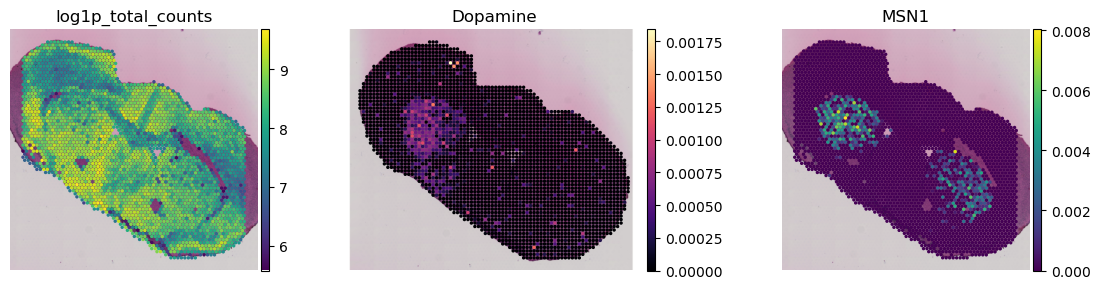

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

sc.pl.spatial(rna, color='log1p_total_counts', ax=axes[0], **kwargs, show=False)
sc.pl.spatial(msi, color='Dopamine', cmap='magma', ax=axes[1], **kwargs, show=False)
sc.pl.spatial(ct, color='MSN1', cmap='viridis', ax=axes[2], **kwargs, show=False)

fig.subplots_adjust(wspace=0, hspace=0)
fig.tight_layout()

/var/folders/5l/h1hwx8xd0dqc3v_jy3f1tbwc0000gn/T/ipykernel_34744/2138788489.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


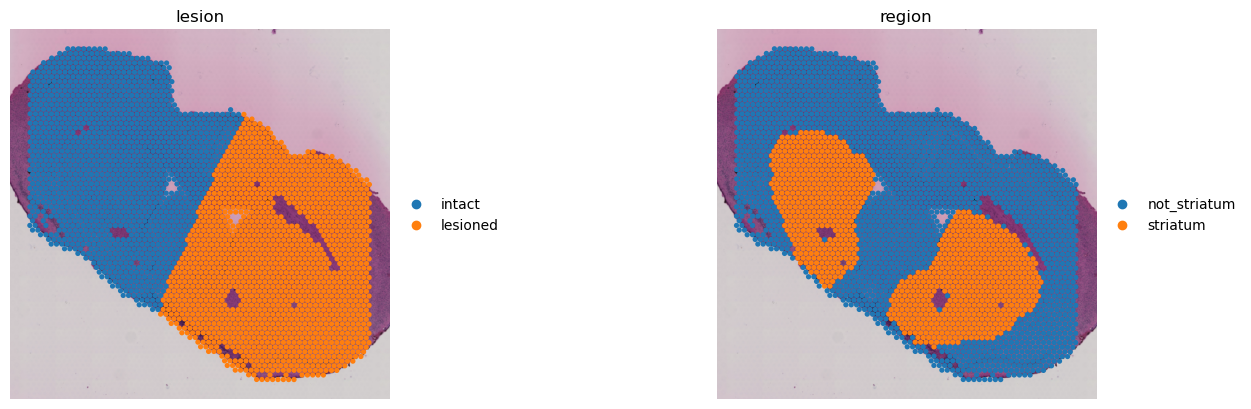

In [13]:
sc.pl.spatial(rna, color=['lesion', 'region'], **kwargs, wspace=0.25)

In [14]:
sc.pp.highly_variable_genes(rna, flavor='cell_ranger', n_top_genes=5000)
sc.pp.highly_variable_genes(msi, flavor='cell_ranger', n_top_genes=150)
ct.var['cv'] = ct.X.toarray().var(axis=0) / ct.X.toarray().mean(axis=0)
ct.var['highly_variable'] = ct.var['cv'] > np.percentile(ct.var['cv'], 20)

In [15]:
msi = msi[:, msi.var['highly_variable']]
rna = rna[:, rna.var['highly_variable']]
ct = ct[:, ct.var['highly_variable']]

In [16]:
sc.pp.scale(msi, max_value=5)

/Users/max/.micromamba/envs/sc_env/lib/python3.12/functools.py:912: UserWarning: Received a view of an AnnData. Making a copy.
/Users/max/.micromamba/envs/sc_env/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.


In [17]:
metalinks = li.rs.get_metalinks(tissue_location='Brain',
                                biospecimen_location='Cerebrospinal Fluid (CSF)',
                                source=['CellPhoneDB', 'NeuronChat']
                                )
metalinks.head()

Database downloaded and saved to /Users/max/Documents/repositories/MSB_project/notebooks/metalinksdb.db (13910016 bytes).


,hmdb,uniprot,gene_symbol,metabolite,mor,transport_direction,type,source
0,HMDB0000870,P25021,HRH2,Histamine,0,None,lr,CellPhoneDB
1,HMDB0000870,P25021,HRH2,Histamine,1,None,lr,CellPhoneDB
2,HMDB0000870,P35367,HRH1,Histamine,0,None,lr,CellPhoneDB
3,HMDB0000870,P35367,HRH1,Histamine,1,None,lr,CellPhoneDB
4,HMDB0000870,Q9H3N8,HRH4,Histamine,0,None,lr,CellPhoneDB


In [18]:
map_df = li.rs.get_hcop_orthologs(columns=['human_symbol', 'mouse_symbol'],
                                  min_evidence=3
                                  ).rename(columns={'human_symbol':'source',
                                                   'mouse_symbol':'target'})

/Users/max/.micromamba/envs/sc_env/lib/python3.12/site-packages/liana/resource/_orthology.py:204: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


In [19]:
metalinks = li.rs.translate_column(resource=metalinks,
                                   map_df=map_df,
                                   column='gene_symbol',
                                   one_to_many=1)
metalinks.head()

,hmdb,uniprot,gene_symbol,metabolite,mor,transport_direction,type,source
0,HMDB0000870,P25021,Hrh2,Histamine,0,None,lr,CellPhoneDB
1,HMDB0000870,P25021,Hrh2,Histamine,1,None,lr,CellPhoneDB
2,HMDB0000870,P35367,Hrh1,Histamine,0,None,lr,CellPhoneDB
3,HMDB0000870,P35367,Hrh1,Histamine,1,None,lr,CellPhoneDB
4,HMDB0000870,Q9H3N8,Hrh4,Histamine,0,None,lr,CellPhoneDB
